In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, nltk, os, glob, pickle
from utils import plot_style, norm01, generate_stim; plot_style();
import torch

### Objectives
* 

stim.shape (time, features): (100, 10)
event_lengths: [10  9 11 10  8 10 12 11  8 11], (n = 10, (sum=100)
event_templates.shape (events, features): (10, 10)
autoreg_directions: [1 0 1 0 1 0 0 1 0 1], (n = 10)
autoreg_features: [array([6, 0, 8]), array([8, 1]), array([0, 6]), array([3, 1, 9, 5]), array([4, 0, 1, 3]), array([1, 8, 3, 9, 2]), array([0, 5, 4, 2, 1]), array([4, 1, 8]), array([5, 0, 8, 2, 3]), array([6, 9, 3, 4])], (n = 10)


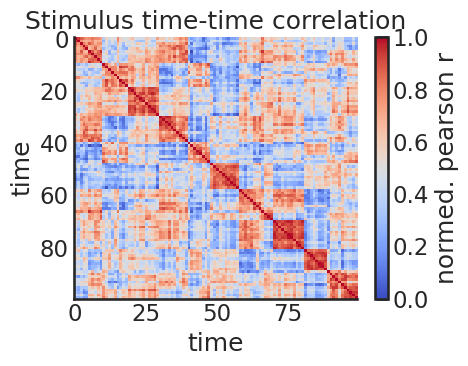

In [2]:
N_TRIALS = 50
trials = [generate_stim(seed=i) for i in range(N_TRIALS)]

trial = trials[0]
print(f'stim.shape (time, features): {trial["stim"].shape}')
print(f'event_lengths: {trial["event_lengths"]}, (n = {len(trial["event_lengths"])}, (sum={trial["event_lengths"].sum()})')
print(f'event_templates.shape (events, features): {trial["event_templates"].shape}')
print(f'autoreg_directions: {trial["autoreg_directions"]}, (n = {len(trial["autoreg_directions"])})')
print(f'autoreg_features: {trial["autoreg_features"]}, (n = {len(trial["autoreg_features"])})')

fig, ax = plt.subplots(figsize=(5,4))
ax.set(title='Stimulus time-time correlation', xlabel='time', ylabel='time')
im = ax.imshow(norm01(np.corrcoef(trial["stim"])), aspect='auto', cmap='coolwarm', vmin=0, vmax=1,
               origin='upper', interpolation='nearest')
plt.colorbar(im, ax=ax, label='normed. pearson r')
plt.tight_layout()
plt.show()


/home/nuttidalab/miniconda3/envs/narrative_map/lib/python3.11/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


final loss: 0.00324


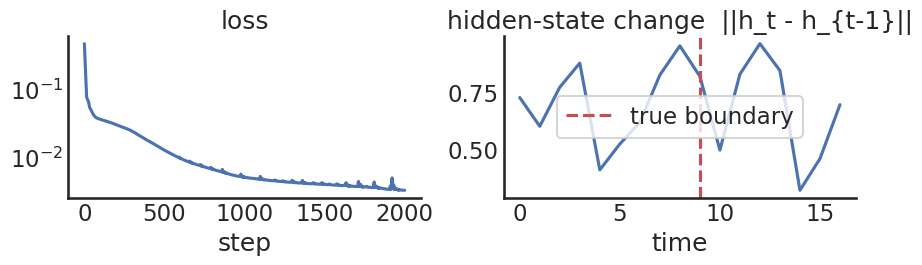

In [3]:
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt

# first TWO events concatenated
L2 = int(trial["event_lengths"][0] + trial["event_lengths"][1])
seq = trial["stim"][:L2].astype('float32')          # (L2, 10)
boundary = int(trial["event_lengths"][0])           # index where event 1 -> event 2

X = torch.tensor(seq[:-1]).unsqueeze(0)    # (1, L2-1, 10)
Y = torch.tensor(seq[1:])                  # (L2-1, 10)

# --- model ---
H = 8
gru     = nn.GRU(input_size=10, hidden_size=H, batch_first=True)
readout = nn.Linear(H, 10)
opt = torch.optim.Adam(list(gru.parameters()) + list(readout.parameters()), lr=1e-2)

# --- train ---
losses = []
for step in range(2000):
    h_seq, _ = gru(X)                       # (1, L2-1, H)
    pred = readout(h_seq).squeeze(0)        # (L2-1, 10)
    loss = ((pred - Y) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
print(f"final loss: {losses[-1]:.5f}")

# --- hidden-state change across the sequence ---
with torch.no_grad():
    h_seq, _ = gru(X)                       # (1, L2-1, H)
    h = h_seq.squeeze(0).numpy()            # (L2-1, H)
dh = np.linalg.norm(np.diff(h, axis=0), axis=1)   # ||h_t - h_{t-1}||, length L2-2

# --- plot ---
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(losses); ax[0].set(title='loss', xlabel='step', yscale='log')
ax[1].plot(dh)
ax[1].axvline(boundary - 1, color='r', ls='--', label='true boundary')
ax[1].set(title='hidden-state change  ||h_t - h_{t-1}||', xlabel='time'); ax[1].legend()
plt.tight_layout(); plt.show()

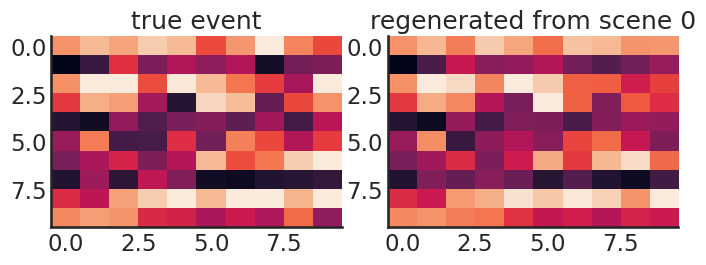

In [4]:
# free-running rollout on the first event
event = trial["stim"][:trial["event_lengths"][0]].astype('float32')   # (L, 10)
L = len(event)

with torch.no_grad():
    seed = torch.tensor(event[0]).view(1, 1, 10)     # only scene 0
    h = None
    gen = [event[0]]
    for _ in range(L - 1):
        out, h = gru(seed, h)            # carry hidden state forward
        nxt = readout(out).squeeze()     # predicted next scene
        gen.append(nxt.numpy())
        seed = nxt.view(1, 1, 10)        # feed prediction back in
gen = np.array(gen)                      # (L, 10)

# compare regenerated vs true event
fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(event.T, aspect='auto', vmin=0, vmax=1); ax[0].set(title='true event')
ax[1].imshow(gen.T,   aspect='auto', vmin=0, vmax=1); ax[1].set(title='regenerated from scene 0')
plt.tight_layout(); plt.show()